### 🧠 Answer Synthesis from Multiple Sources
✅ What Is It?

Answer synthesis from multiple sources is the process where an AI agent collects information from different retrieval tools or knowledge bases, and merges that information into a single, coherent, and contextually rich answer.

This is a core capability in Agentic RAG, where the system is more than just a simple retriever — it plans, retrieves, and then synthesizes an answer that draws from multiple sources.

🎯 Why It’s Needed
Most real-world queries are:
- Multifaceted (require multiple types of information)
- Ambiguous or incomplete (need refinement)
- Open-ended (don’t map to a single document or source)

🔍 This makes retrieving from a single vector DB insufficient.

Instead, we want an agent that can:

- Decide what to fetch from where (retrieval planning)
- Retrieve content from multiple tools (e.g., Wikipedia, PDFs, APIs, SQL)
- Evaluate and merge that context
- Produce a single human-like response

In [1]:
import ssl
import certifi
ssl_context = ssl.create_default_context(cafile=certifi.where())

In [2]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_community.document_loaders import TextLoader
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from typing import TypedDict, List
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import StateGraph, END
from IPython.display import Markdown, display

In [3]:
load_dotenv()

True

In [4]:
# setting up environment variables
groq_key = os.getenv("GROQ_API_KEY")
openai_key = os.getenv("OPENAI_API_KEY")

if openai_key is not None:
    os.environ["OPENAI_API_KEY"] = openai_key
else:
    raise ValueError("OPENAI_API_KEY environment variable is not set.")

if groq_key is not None:
    os.environ["GROQ_API_KEY"] = groq_key
else:
    raise ValueError("GROQ_API_KEY environment variable is not set.")

In [5]:
llm = init_chat_model("openai:gpt-4o")

In [6]:
def internal_doc_search(query: str):
    print("📄 Searching Internal Docs...")
    docs = TextLoader('internal_docs.txt', encoding="utf-8").load()
    splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
    chunks = splitter.split_documents(docs)
    vs = FAISS.from_documents(chunks, OpenAIEmbeddings())
    retriever = vs.as_retriever()
    return retriever.invoke(query)

def youtube_search(query: str):
    # Mocked YouTube transcript text
    print("▶️ Searching YouTube...")
    content = """
    This video explains how agentic AI systems rely on feedback loops, memory, and tool use.
    It compares them to traditional pipeline-based LLMs. Temporal reasoning and autonomous tasking are emphasized.
    """
    doc = Document(page_content=content, metadata={"source": "youtube"})
    vectorstore = FAISS.from_documents([doc], OpenAIEmbeddings())
    retriever = vectorstore.as_retriever()
    return retriever.invoke(query)

def wikipedia_search(query: str) -> str:
    print("🌐 Searching Wikipedia...")
    wiki = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    return wiki.run(query) 


def arxiv_search(query: str) -> str:
    print("📄 Searching ArXiv...")
    arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=5000)
    result = arxiv.run(query)
    return result or "No relevant papers found."

In [7]:
# LangGraph State Definition
class MultiSourceRAGState(TypedDict):
    question: str
    text_docs: List[Document]
    yt_docs: List[Document]
    wiki_context: str
    arxiv_context: str
    final_answer: str

In [8]:
### Retrieval Nodes
def retrieve_text(state: MultiSourceRAGState) -> dict:
    docs = internal_doc_search(state['question'])
    return {"text_docs": docs}

def retrieve_yt(state: MultiSourceRAGState) -> dict:
    docs = youtube_search(state['question'])
    return {"yt_docs": docs}

def retrieve_wikipedia(state: MultiSourceRAGState) -> dict:
    result = wikipedia_search(state['question'])
    return {"wiki_context": result}

def retrieve_arxiv(state: MultiSourceRAGState) -> dict:
    result = arxiv_search(state['question'])
    return {"arxiv_context": result}

In [9]:
## synthesize
def synthesize_answer(state: MultiSourceRAGState) -> dict:
    
    context = ""

    context += "\n\n[Internal Docs]\n" + "\n".join([doc.page_content for doc in state['text_docs']])
    context += "\n\n[YouTube Transcript]\n" + "\n".join([doc.page_content for doc in state['yt_docs']])
    context += "\n\n[Wikipedia]\n" + state['wiki_context']
    context += "\n\n[ArXiv]\n" + state['arxiv_context']

    prompt = PromptTemplate(
        template = """
        You have retrieved relevant context from multiple sources. Now synthesize a complete and coherent answer.

        Question: 
        {question}

        Context:
        {context}

        Final Answer:
        """,
        input_variables=['question', 'context']
    )
    chain = prompt|llm|StrOutputParser()
    answer = chain.invoke({"question": state['question'], 'context': context})
    return {"final_answer": answer}

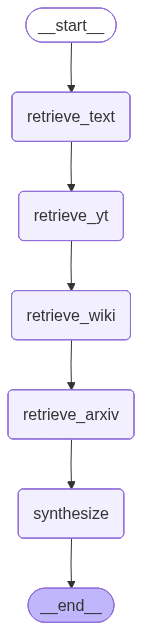

In [10]:
builder = StateGraph(MultiSourceRAGState)

builder.add_node("retrieve_text", retrieve_text)
builder.add_node("retrieve_yt", retrieve_yt)
builder.add_node("retrieve_wiki", retrieve_wikipedia)
builder.add_node("retrieve_arxiv", retrieve_arxiv)
builder.add_node("synthesize", synthesize_answer)

builder.set_entry_point("retrieve_text")
builder.add_edge("retrieve_text", "retrieve_yt")
builder.add_edge("retrieve_yt", "retrieve_wiki")
builder.add_edge("retrieve_wiki", "retrieve_arxiv")
builder.add_edge("retrieve_arxiv", "synthesize")
builder.add_edge("synthesize", END)

graph = builder.compile()
graph

In [11]:
question = "What are transformer agents and how are they evolving in recent research?"
state = MultiSourceRAGState(question=question)
result = graph.invoke(state)

print("✅ Final Answer:\n")
display(Markdown(result["final_answer"]))

📄 Searching Internal Docs...
▶️ Searching YouTube...
🌐 Searching Wikipedia...
📄 Searching ArXiv...
✅ Final Answer:



Transformer agents are advanced AI systems that leverage transformer models, evolving beyond static configurations to become more adaptable and autonomous. Transformers, originally introduced in 2017, replaced recurrent neural networks for language tasks, enabling efficient parallelization and handling of longer contexts. Large language models (LLMs) such as GPT and BERT exemplify this transition, showcasing the capability for tasks like summarization, translation, and reasoning.

Recent research explores transforming these static LLMs into dynamic agents capable of evolving with environmental interactions and feedback. This involves self-evolving techniques that automatically enhance agent systems, adapting to changing environments, which is a critical step for developing lifelong agentic systems. The research emphasizes feedback loops and interaction data, enabling agents to autonomously refine their capabilities.

Furthermore, the development of specialized transformer variants addresses domain-specific constraints and optimization challenges. For example, EfficientFormer is optimized for mobile and edge environments, whereas Reformer focuses on memory efficiency. These advancements show significant improvements in inference times, resource utilization, and integration capabilities.

Additionally, the area of multi-agent reinforcement learning (MARL) is evolving, with communication between agents playing a central role. Through effective communication strategies, agents can improve their coordination, enhance overall learning performance, and achieve complex objectives more efficiently.

Overall, transformer agents are transitioning from static LLMs to dynamic, self-evolving systems through innovative techniques in model optimization, feedback integration, and multi-agent coordination, paving the way for more sophisticated autonomous AI agents.